# Проверка гипотез в бизнесе: анализ сервиса проката самокатов GoFast

- Автор: Петрунин Богдан
- Дата: 29.09.2026

## Цели и задачи проекта

**Контекст.** Сервис проката самокатов GoFast предоставил данные о своих пользователях, их поездках за 2021 год и стоимости услуг в подписках. Продакт-менеджеры хотят увеличить число пользователей с платной подпиской и перед запуском акций должны понять, чем подписчики отличаются от остальных пользователей.

**Цель:** изучить демографию пользователей и особенности использования самокатов, а также оценить возможную выгоду от распространения подписки Ultra.

**Задачи:**
- загрузить данные и провести предобработку (типы данных, пропуски, дубликаты);
- исследовать пользователей и поездки: города, соотношение подписок, возраст, длительность поездок;
- объединить таблицы и сравнить поведение пользователей с подпиской и без неё;
- рассчитать месячную выручку по каждому пользователю;
- проверить три продуктовые гипотезы о времени поездок, их дистанции и выручке подписчиков;
- смоделировать длительность и дистанцию поездок нормальным распределением и оценить долю длительных поездок и критическую дистанцию.

## Описание данных

Для анализа предоставлено три таблицы.

Таблица с пользователями `users_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `name` — имя пользователя.

- `age` — возраст.

- `city` — город.

- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`

- `subscription_type` — тип подписки.

- `minute_price` — стоимость одной минуты поездки по этой подписке.

- `start_ride_price` — стоимость начала поездки.

- `subscription_fee` — стоимость ежемесячного платежа.

## Содержание

1. Загрузка данных
2. Предобработка данных
3. Исследовательский анализ данных
4. Объединение данных
5. Подсчёт выручки
6. Проверка гипотез
7. Распределения
8. Общий вывод

## 1. Загрузка данных

Загрузим три таблицы — пользователи, поездки и подписки — и познакомимся с их содержимым.

### 1.1 Импорт библиотеки

Для работы с таблицами импортируем библиотеку `pandas`.

In [1]:
import pandas as pd

### 1.2 Чтение данных

Считаем три CSV-файла в датафреймы `df_users_go`, `df_rides_go` и `df_subscriptions_go`. Данные лежат по ссылкам:

- https://code.s3.yandex.net/datasets/users_go.csv
- https://code.s3.yandex.net/datasets/rides_go.csv
- https://code.s3.yandex.net/datasets/subscriptions_go.csv

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv') 

### 1.3 Первые строки таблиц

Выведем первые пять строк каждого датафрейма, чтобы увидеть структуру данных.

In [3]:
df_users_go.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### 1.4 Количество строк

Посчитаем строки в каждой таблице (пользователи, поездки, подписки), чтобы оценить объём данных.

In [6]:
print(len(df_users_go), len(df_rides_go), len(df_subscriptions_go))

1565 18068 2


**Промежуточный вывод.** В таблице пользователей 1565 строк, в таблице поездок — 18 068, в таблице подписок — 2 строки (тарифы `free` и `ultra`). Объём данных достаточный для анализа, структура таблиц соответствует описанию.

## 2. Предобработка данных

Перед анализом проверим качество данных: приведём типы, добавим нужные признаки и обработаем пропуски и дубликаты.

### 2.1 Типы данных

Проверим типы данных в таблице поездок `df_rides_go`.

In [7]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

Столбец `date` имеет тип `object`, то есть хранится как строка, — его нужно привести к типу даты.

### 2.2 Преобразование формата даты

Приведём столбец `date` к типу даты с помощью `pd.to_datetime()`.

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

### 2.3 Столбец с номером месяца

На основе столбца `date` создадим столбец `month` с номером месяца — он понадобится для группировки данных по месяцам.

In [9]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### 2.4 Пропуски и дубликаты

Определим количество пропусков и полных дубликатов в таблице пользователей `df_users_go`.

In [10]:
df_users_go.isna().sum().sum()
df_users_go.duplicated().sum()
print(df_users_go.isna().sum().sum(), df_users_go.duplicated().sum() )

0 31


Пропусков в таблице пользователей нет, но обнаружено 31 полное дублирование строк.

### 2.5 Обработка пропусков и дубликатов

Пропусков нет, но на всякий случай заполним их нулями, а полные дубликаты удалим.

In [11]:
df_users_go = df_users_go.fillna(0)
df_users_go = df_users_go.drop_duplicates()

### 2.6 Округление длительности поездки

Оплата в сервисе взимается за целое число минут, поэтому округлим длительность поездки `duration` до целого числа и приведём столбец к типу `int`.

In [12]:
df_rides_go['duration'] = df_rides_go['duration'].round()
df_rides_go['duration'] = df_rides_go['duration'].astype(int)

**Промежуточный вывод по предобработке.**
- Столбец `date` приведён к типу даты, добавлен столбец `month`.
- Пропусков в данных нет, удалено 31 дублирующаяся строка: в таблице осталось 1534 уникальных пользователя.
- Длительность поездок округлена до целых минут — теперь её можно использовать для расчёта выручки.

## 3. Исследовательский анализ данных

Изучим и визуализируем информацию о пользователях (города, подписка, возраст) и поездках (длительность).

### 3.1 Импорт библиотеки для визуализации

Импортируем `matplotlib.pyplot`.

In [13]:
import matplotlib.pyplot as plt

### 3.2 Пользователи по городам

Посчитаем количество пользователей в каждом городе и отсортируем города по убыванию.

In [14]:
users_by_city_count = df_users_go['city'].value_counts()
print(users_by_city_count) 

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


Пользователи распределены по восьми городам достаточно равномерно: больше всего их в Пятигорске (219), меньше всего — в Москве (168).

### 3.3 Пользователи с подпиской и без

Посчитаем, сколько пользователей используют каждый тип подписки.

In [15]:
subscription_type_count = df_users_go['subscription_type'].value_counts()
print(subscription_type_count)

free     835
ultra    699
Name: subscription_type, dtype: int64


Пользователей без подписки (`free`) немного больше — 835 против 699 пользователей с подпиской `ultra`.

### 3.4 Соотношение пользователей с подпиской и без

Построим круговую диаграмму с долями пользователей `free` и `ultra`: пользователи без подписки отметим красным цветом, подписчики — зелёным.

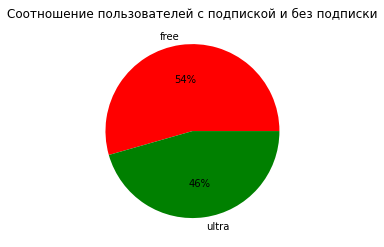

In [16]:
subscription_type_count.plot(
    kind= 'pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct= '%.0f%%',
    ylabel='',
    colors=['red','green']
)

plt.show()

Доля пользователей без подписки — 54%, с подпиской — 46%. Платной подпиской пользуется почти половина аудитории.

### 3.5 Возраст пользователей

Построим гистограмму возраста. Число интервалов зададим как разницу между максимальным и минимальным возрастом, чтобы каждому возрасту соответствовал свой столбец.

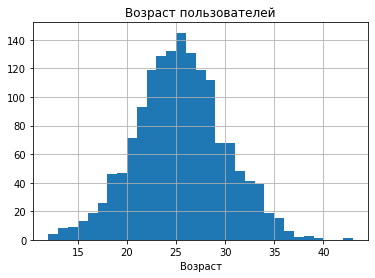

In [17]:

n_bins = df_users_go['age'].max() - df_users_go['age'].min()

df_users_go['age'].hist(bins=n_bins)

plt.title('Возраст пользователей')

plt.xlabel('Возраст')

plt.show()

Возраст пользователей — примерно от 12 до 43 лет, распределение близко к нормальному. Основная масса пользователей — люди 20–30 лет, пик приходится на 25 лет.

### 3.6 Несовершеннолетние пользователи

Рассчитаем долю пользователей младше 18 лет.

In [18]:
count_under_18 = (df_users_go['age'] < 18).sum()
total_users = len(df_users_go)
users_under_18_ratio = round(100 * count_under_18 / total_users)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


Несовершеннолетние составляют около 5% пользователей — сервис используют в основном взрослые.

### 3.7 Характеристики длительности поездки

Длительность поездки — важная метрика сервиса: слишком долгие поездки быстрее изнашивают самокаты, а слишком короткие могут говорить о неудовлетворённости клиентов. Посчитаем среднее, стандартное отклонение и 25-й и 75-й процентили длительности.

In [19]:
rides_duration = df_rides_go['duration'].describe()
duration_mean = round(rides_duration['mean'])
duration_std = round(rides_duration['std'])

duration_pct25 = round(rides_duration['25%'])
duration_pct75 = round(rides_duration['75%'])

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


**Промежуточный вывод по исследовательскому анализу.**
- Пользователи равномерно распределены по 8 городам; лидирует Пятигорск (219 пользователей).
- Подписку Ultra оформили 46% пользователей, без подписки — 54%.
- Основная аудитория — люди 20–30 лет, несовершеннолетних около 5%.
- Средняя длительность поездки — 18 минут при стандартном отклонении 6 минут; большинство поездок длится от 14 до 22 минут.

## 4. Объединение данных

Объединим три таблицы в один датафрейм, чтобы сравнивать поведение пользователей с подпиской и без неё.

### 4.1 Объединение пользователей и поездок

Объединим `df_users_go` и `df_rides_go` методом `merge()` по общему столбцу `user_id`. Результат сохраним в датафрейм `df`.

In [20]:
df = df_users_go.merge(df_rides_go)

### 4.2 Присоединение информации о подписках

Присоединим к `df` данные о тарифах из `df_subscriptions_go` — они связаны по столбцу `subscription_type`.

In [21]:
df = df.merge(df_subscriptions_go)

### 4.3 Проверка размера объединённого датафрейма

Выведем первые строки и размер `df`, чтобы убедиться, что при объединении не потерялись записи.

In [22]:
# Выводим первые строки датафрейма
display(df.head())

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


Число строк в `df` (18 068) совпадает с числом поездок в исходной таблице, то есть ни одна поездка не потерялась.

### 4.4 Пользователи с подпиской и без

Разделим `df` на два датафрейма: `df_ultra` — поездки пользователей с подпиской и `df_free` — поездки пользователей без подписки. Они понадобятся для сравнения групп и проверки гипотез.

In [23]:
df_ultra =df[df['subscription_type'] == 'ultra']
df_free = df[df['subscription_type'] == 'free'] 

### 4.5 Длительность поездок в двух группах

Построим на одном графике гистограммы длительности поездок пользователей с подпиской и без, а также рассчитаем среднюю длительность поездки в каждой группе.

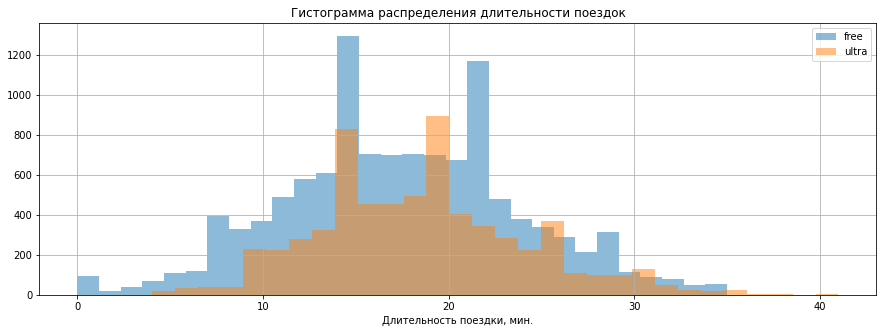

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [24]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))
df_free['duration'].hist(bins=30, label='free', alpha=0.5)
df_ultra['duration'].hist(bins=30, label='ultra', alpha=0.5)
plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()
plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

**Промежуточный вывод.** Распределения длительности в обеих группах похожи. Подписчики в среднем ездят дольше — 19 минут против 17 у пользователей без подписки. Также у пользователей без подписки заметна группа совсем коротких поездок (около одной минуты).

## 5. Подсчёт выручки

Теперь, когда данные о поездках объединены с тарифами, можно рассчитать выручку сервиса по каждому пользователю за каждый месяц.

### 5.1 Группировка данных

Сгруппируем `df` по столбцам `user_id`, `name`, `subscription_type` и `month`. Параметр `as_index=False` сохранит эти столбцы обычными, а не индексами.

In [25]:
gp_cols = ['user_id', 'name', 'subscription_type', 'month']

df_gp = df.groupby(gp_cols, as_index=False)

### 5.2 Агрегированные метрики

Для каждой группы (пользователь — месяц) посчитаем суммарное расстояние, суммарное время и количество поездок, а также сохраним параметры тарифа. Результат запишем в датафрейм `df_agg`.

In [26]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration','sum'),
    rides_count=('duration','count') ,
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
) 

### 5.3 Функция для расчёта выручки

Напишем функцию `calculate_monthly_revenue(row)`, которая считает месячную выручку по формуле:

`monthly_revenue` = `start_ride_price` × `rides_count` + `minute_price` × `total_duration` + `subscription_fee`

Здесь `start_ride_price × rides_count` — выручка за старт поездок, `minute_price × total_duration` — выручка за время использования, `subscription_fee` — ежемесячный платёж за подписку.

In [27]:
def calculate_monthly_revenue(row):
    monthly_revenue = (
        row['start_ride_price'] * row['rides_count'] + 
        row['minute_price'] * row['total_duration'] + 
        row['subscription_fee']
    )
    return monthly_revenue

### 5.4 Столбец с месячной выручкой

Применим функцию к каждой строке `df_agg` и сохраним результат в столбец `monthly_revenue`.

In [28]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### 5.5 Пользователь с максимальной выручкой

Найдём пользователя с наибольшей суммарной выручкой за весь период и посмотрим, сколько он ездил и сколько принёс в каждом месяце.

In [29]:
# 1. Считаем суммарную выручку по каждому пользователю
total_revenue_per_user = df_agg.groupby('user_id')['monthly_revenue'].sum()

# 2. Находим ID пользователя с максимальной выручкой
max_revenue_user_id = total_revenue_per_user.idxmax()

# 3. Фильтруем данные и выводим отчет
cols = ['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']
result = df_agg[df_agg['user_id'] == max_revenue_user_id][cols]

display(result)

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


Больше всего выручки за период принёс пользователь Александр (`user_id` 1236). Выручка от месяца к месяцу зависит от числа его поездок и их длительности.

## 6. Проверка гипотез

Продакт-менеджеры хотят увеличить число подписчиков. Прежде чем проводить акции, проверим три гипотезы о поведении пользователей с подпиской. Уровень значимости во всех тестах — α = 0,05.

### 6.1 Импорт библиотеки SciPy

Импортируем `scipy.stats` для статистических тестов.

In [30]:
import scipy.stats as st

### 6.2 Вспомогательная функция для интерпретации результатов

Чтобы одинаково интерпретировать все тесты, напишем функцию `print_stattest_results(p_value, alpha)`. Если `p_value` меньше `alpha` (по умолчанию 0,05), принимаем альтернативную гипотезу, иначе — нулевую опровергнуть нельзя. Проверим работу функции на значениях 0,0001 и 0,1.

In [31]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
     # Сравниваем p-value с уровнем значимости alpha
    if p_value < alpha:
        # Если p-value меньше порога, отклоняем нулевую гипотезу в пользу альтернативной
        print(f"Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.")
    else:
        # Если p-value больше или равно порогу, не можем отклонить нулевую гипотезу
        print(f"Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.")
print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.3 Гипотеза 1: длительность поездок подписчиков

Тратят ли пользователи с подпиской больше времени на поездки? Если да, то они могут быть выгоднее для компании.

- **H₀:** средняя длительность поездки у пользователей с подпиской и без подписки одинаковая.
- **H₁:** средняя длительность поездки у пользователей с подпиской больше, чем у пользователей без подписки.

Используем односторонний t-тест для двух независимых выборок на неагрегированных данных о длительности каждой поездки (`df_ultra` и `df_free`), а также посчитаем средние значения.

In [32]:

ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')

p_value = results.pvalue


print_stattest_results(p_value)

ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


**Вывод.** p-value ≈ 3,2·10⁻³⁵ намного меньше 0,05, поэтому принимаем альтернативную гипотезу: поездки пользователей с подпиской в среднем длиннее — 18,55 мин против 17,39 мин у пользователей без подписки. Разница небольшая (около 1,2 минуты), но статистически значимая.

### 6.4 Гипотеза 2: дистанция поездки подписчиков и износ самоката

Расстояние одной поездки в 3130 метров оптимально с точки зрения износа самоката. Проверим, можно ли сказать, что подписчики в среднем не проезжают за поездку больше этого значения.

- **H₀:** средняя дистанция поездки пользователей с подпиской равна 3130 м.
- **H₁:** средняя дистанция поездки пользователей с подпиской больше 3130 м.

Используем односторонний t-тест для одной выборки (`ttest_1samp`) на данных о дистанции каждой поездки подписчиков из `df_ultra`.

In [33]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']


results = st.ttest_1samp(ultra_distance,popmean=null_hypothesis,alternative='greater')
p_value =results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


**Вывод.** p-value ≈ 0,92 больше 0,05 — нулевую гипотезу опровергнуть нельзя. Нет оснований считать, что подписчики в среднем проезжают за поездку больше 3130 м, то есть по износу самокатов они укладываются в оптимальное значение.

### 6.5 Гипотеза 3: выручка от подписчиков

Приносят ли пользователи с подпиской больше выручки, чем пользователи без подписки?

- **H₀:** средняя месячная выручка от пользователей с подпиской и без подписки одинаковая.
- **H₁:** средняя месячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.

Используем односторонний t-тест для двух независимых выборок на агрегированных данных `df_agg` (столбец `monthly_revenue`) и посчитаем среднюю выручку по тарифам.

In [34]:

revenue_ultra = df_agg.query('subscription_type == "ultra"')['monthly_revenue']

# Берем колонку monthly_revenue только для пользователей без подписки Free
revenue_free = df_agg.query('subscription_type == "free"')['monthly_revenue']

# 2. Проводим односторонний t-тест (alternative='greater')
# Проверяем гипотезу: средняя выручка Ultra > средняя выручка Free
results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')

# 3. Получаем p-value
p_value = results.pvalue

# 4. Выводим интерпретацию результатов
print_stattest_results(p_value)

# 5. Рассчитываем средние значения и округляем до целого
mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

# 6. Выводим средние значения
print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


**Вывод.** p-value ≈ 1,7·10⁻³⁷ намного меньше 0,05, поэтому принимаем альтернативную гипотезу: месячная выручка от подписчиков выше — в среднем 359 ₽ против 322 ₽ у пользователей без подписки.

**Промежуточный вывод по гипотезам.** Пользователи с подпиской ездят дольше, не превышают оптимальную для самоката дистанцию и приносят больше выручки, поэтому расширение подписки выгодно для компании.

## 7. Распределения

В компании появилась идея предлагать дополнительную скидку подписчикам, которые совершают длительные поездки (более 30 минут). Нужно оценить долю таких поездок.

Наши данные охватывают только часть поездок, а нас интересует вся генеральная совокупность. Поэтому смоделируем длительность поездки нормальным распределением, взяв в качестве параметров выборочное среднее и стандартное отклонение.

### 7.1 Выборочное среднее и стандартное отклонение

Скидку планируется предлагать подписчикам, поэтому рассчитаем среднюю длительность (`mu`) и стандартное отклонение (`sigma`) по поездкам пользователей с подпиской. Целевое время `target_time` зададим равным 30 минутам.

In [35]:
# Вычисляем среднее значение длительности поездки для пользователей с подпиской
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение длительности поездки
sigma = df_ultra['duration'].std()

# Задаём целевое время (30 минут)
target_time = 30

# Делаем вывод, округляя значения для отображения, но оставляя mu и sigma полными
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


### 7.2 Вероятность поездки длительностью более 30 минут (CDF)

Функция распределения (CDF) в точке показывает вероятность того, что случайная величина окажется не больше заданного значения. Поэтому вероятность поездки более 30 минут равна `1 − cdf(30)`.

In [36]:


# 1. Создаем объект нормального распределения с параметрами mu и sigma
duration_norm_dist = st.norm(mu, sigma)

# 2. Вычисляем вероятность поездки БОЛЕЕ 30 минут
# cdf(target_time) дает вероятность <= 30
# 1 - cdf(target_time) дает вероятность > 30
prob = round(1 - duration_norm_dist.cdf(target_time), 3)

# 3. Выводим результат
print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


Вероятность поездки подписчика дольше 30 минут — около 2%. Скидка затронет очень небольшую часть поездок и вряд ли заметно повлияет на лояльность.

### 7.3 Вероятность поездки длительностью от 20 до 30 минут (CDF)

Проверим, какая доля поездок приходится на интервал от 20 до 30 минут: возможно, именно для этих пользователей стоит провести промоакцию. Вероятность попадания в интервал — это разность значений CDF на верхней и нижней границах.

In [37]:
# Определяем границы интервала
low = 20
high =30

prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


На интервал от 20 до 30 минут приходится около 37,7% поездок — это значительно больше, чем доля поездок дольше 30 минут, поэтому промоакцию для такой группы стоит рассмотреть.

### 7.4 Критическая дистанция поездки (PPF)

Длительные поездки быстрее изнашивают самокаты, поэтому предлагается ввести доплату за превышение критической дистанции, которая превышается только в 10% поездок. Смоделируем дистанцию нормальным распределением по данным всех пользователей (с подпиской и без) и найдём 90-й процентиль с помощью обратной функции распределения `ppf()`.

In [38]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


Критическая дистанция — около 4 502 метров: 90% поездок короче этого значения.

## Общий вывод

**Данные и предобработка.** Проанализированы данные о 1534 пользователях (после удаления 31 дубликата) и 18 068 поездках. Пропусков в данных нет, типы данных приведены к нужным, длительность поездок округлена до целых минут.

**Портрет пользователей.** Пользователи равномерно распределены по 8 городам (лидер — Пятигорск). Платную подписку Ultra оформили 46% пользователей. Основная аудитория — люди 20–30 лет, несовершеннолетних около 5%. Средняя поездка длится 18 минут (в основном 14–22 минуты).

**Проверка гипотез** (α = 0,05):
- Подписчики ездят дольше: 18,55 мин против 17,39 мин (H₁ принята).
- Средняя дистанция поездки подписчиков не превышает оптимальных 3130 м (H₀ опровергнуть не удалось).
- Подписчики приносят больше месячной выручки: 359 ₽ против 322 ₽ (H₁ принята).

**Моделирование нормальным распределением.**
- Вероятность поездки подписчика дольше 30 минут — около 2%, то есть скидка на длительные поездки затронет очень малую долю пользователей.
- На поездки от 20 до 30 минут приходится около 37,7%: для этой группы промоакция может быть эффективнее.
- 90% поездок короче ≈ 4 502 м — это значение можно рассмотреть как критическую дистанцию для доплаты.

**Рекомендации.** Пользователи с подпиской выгоднее компании: они приносят больше выручки и не создают избыточного износа самокатов, поэтому продвижение подписки оправдано. Скидку на поездки дольше 30 минут вводить нецелесообразно из-за малой доли таких поездок; лучше рассмотреть промоакцию для поездок от 20 до 30 минут и доплату за дистанцию свыше ≈ 4,5 км.